# **Preprocessing Data (Klasifikasi Time Series - Dataset BME)**

In [22]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import joblib
df_train = pd.read_csv('BME_TRAIN.csv')
df_test = pd.read_csv('BME_TEST.csv')

print(f"Data Training: {df_train.shape}")
print(f"Data Testing: {df_test.shape}")

Data Training: (30, 129)
Data Testing: (8, 129)


### 3.1 Cek dan Handling Missing Values

In [23]:
missing_train = df_train. isnull().sum(). sum()
missing_test = df_test. isnull().sum().sum()

print(f"Missing values di data training: {missing_train}")
print(f"Missing values di data testing: {missing_test}")

if missing_train > 0:
    print("Melakukan interpolasi untuk missing values di data training")
    df_train = df_train.interpolate(method='linear', axis=1)
    df_train = df_train. fillna(method='bfill', axis=1)
    df_train = df_train. fillna(method='ffill', axis=1)
    
if missing_test > 0:
    print("Melakukan interpolasi untuk missing values di data testing")
    df_test = df_test.interpolate(method='linear', axis=1)
    df_test = df_test. fillna(method='bfill', axis=1)
    df_test = df_test.fillna(method='ffill', axis=1)

print("Missing values setelah handling:")
print(f"  Training: {df_train.isnull().sum().sum()}")
print(f"  Testing: {df_test. isnull().sum().sum()}")

Missing values di data training: 0
Missing values di data testing: 0
Missing values setelah handling:
  Training: 0
  Testing: 0


### 3.2 Pisahkan Fitur dan Target

In [24]:
X_train = df_train.drop('target', axis=1)
y_train = df_train['target']

X_test = df_test. drop('target', axis=1)
y_test = df_test['target']

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (30, 128)
y_train shape: (30,)
X_test shape: (8, 128)
y_test shape: (8,)


### 3.3 Cek dan Handling Outliers

In [25]:
def count_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((data < lower_bound) | (data > upper_bound)).sum(). sum()
    return outliers

outliers_train = count_outliers_iqr(X_train)
outliers_test = count_outliers_iqr(X_test)

print(f"Jumlah outlier di data training: {outliers_train}")
print(f"Jumlah outlier di data testing: {outliers_test}")
print("Catatan: Outlier tidak dihapus karena bisa jadi bagian dari pola time series")

Jumlah outlier di data training: 259
Jumlah outlier di data testing: 54
Catatan: Outlier tidak dihapus karena bisa jadi bagian dari pola time series


### 3.4 Cek Duplikat Data

In [26]:
duplicates_train = df_train.duplicated(). sum()
duplicates_test = df_test.duplicated(). sum()

print(f"Duplikat di data training: {duplicates_train}")
print(f"Duplikat di data testing: {duplicates_test}")

if duplicates_train > 0:
    print(f"Menghapus {duplicates_train} duplikat di data training")
    df_train = df_train.drop_duplicates()
    X_train = df_train.drop('target', axis=1)
    y_train = df_train['target']

Duplikat di data training: 0
Duplikat di data testing: 0


### 3.5 Encoding Label Target

In [27]:
print("Label asli:")
print(f"  Unique values: {sorted(y_train. unique())}")
print(f"  Distribusi: \n{y_train.value_counts(). sort_index()}")

# Cek apakah label sudah numerik
if y_train.dtype == 'object':
    label_encoder = LabelEncoder()
    y_train = label_encoder.fit_transform(y_train)
    y_test = label_encoder. transform(y_test)
    joblib.dump(label_encoder, 'label_encoder_bme.pkl')
else:
    print("Label sudah dalam format numerik, tidak perlu encoding")

Label asli:
  Unique values: [1, 2, 3]
  Distribusi: 
target
1    10
2    10
3    10
Name: count, dtype: int64
Label sudah dalam format numerik, tidak perlu encoding


### 3.6 Standarisasi Data dengan StandardScaler

In [28]:
print("Statistik SEBELUM standarisasi:")
print(f"  X_train - Mean: {X_train.values.mean():.4f}, Std: {X_train. values.std():.4f}")
print(f"  X_train - Min: {X_train.values. min():.4f}, Max: {X_train.values.max():.4f}")

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nStatistik SETELAH standarisasi:")
print(f"  X_train_scaled - Mean: {X_train_scaled.mean():.6f}, Std: {X_train_scaled.std():.6f}")
print(f"  X_train_scaled - Min: {X_train_scaled.min():.4f}, Max: {X_train_scaled.max():.4f}")

Statistik SEBELUM standarisasi:
  X_train - Mean: 0.0584, Std: 0.6398
  X_train - Min: -1.3960, Max: 1.3700

Statistik SETELAH standarisasi:
  X_train_scaled - Mean: 0.000000, Std: 1.000000
  X_train_scaled - Min: -3.3188, Max: 5.1907


### 3.7 Visualisasi Perbandingan Sebelum dan Sesudah Scaling

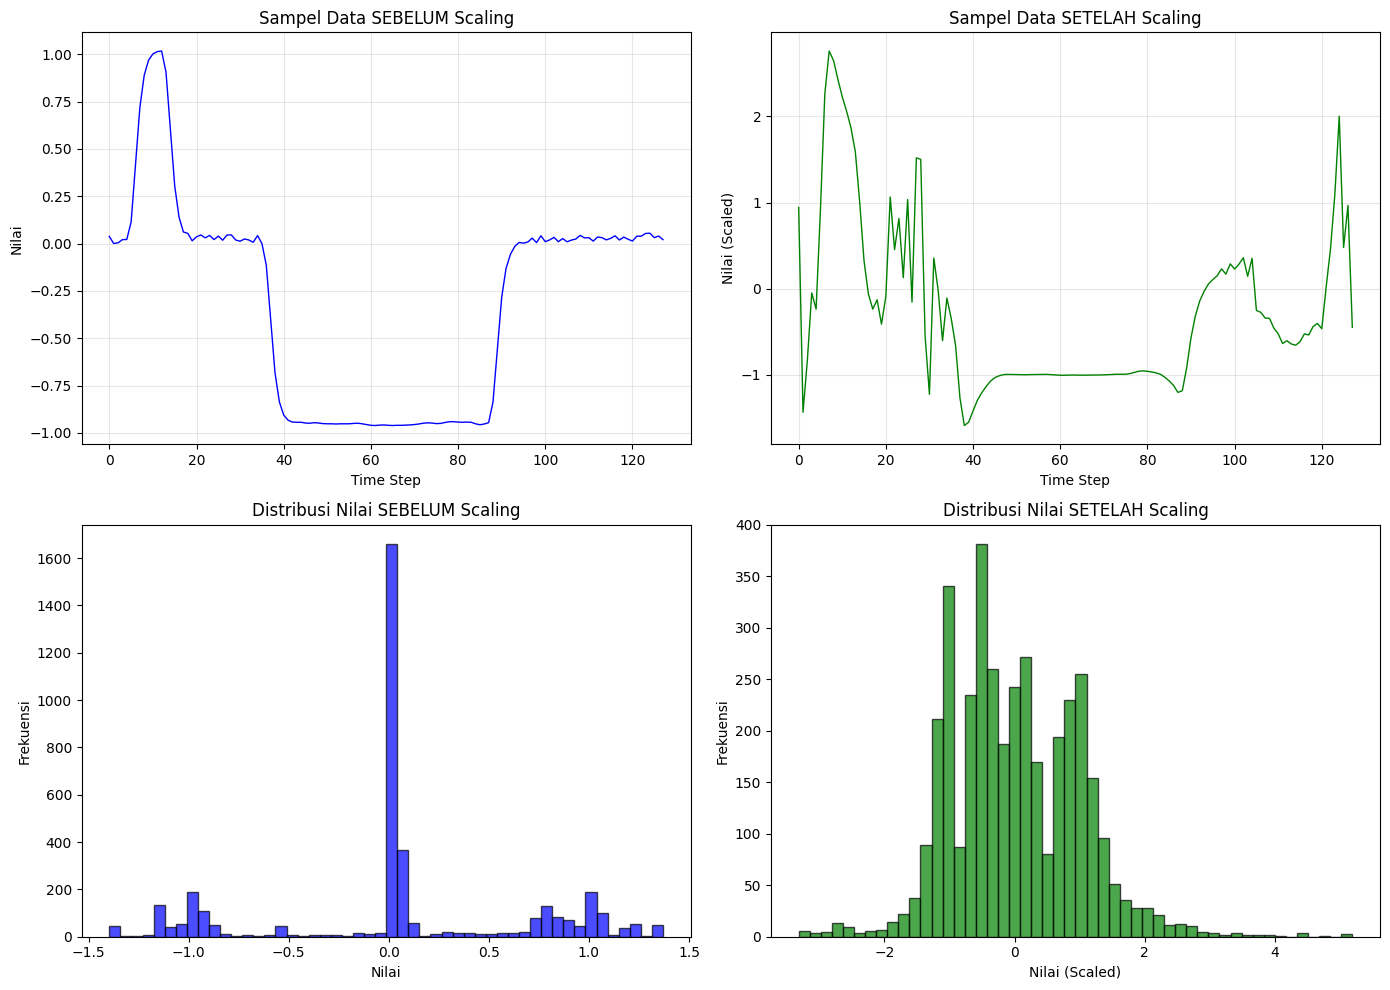

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Sampel 1 data sebelum scaling
ax1 = axes[0, 0]
ax1.plot(X_train. iloc[0]. values, color='blue', linewidth=1)
ax1.set_title('Sampel Data SEBELUM Scaling')
ax1. set_xlabel('Time Step')
ax1. set_ylabel('Nilai')
ax1.grid(True, alpha=0.3)

# Sampel 1 data setelah scaling
ax2 = axes[0, 1]
ax2.plot(X_train_scaled[0], color='green', linewidth=1)
ax2.set_title('Sampel Data SETELAH Scaling')
ax2.set_xlabel('Time Step')
ax2.set_ylabel('Nilai (Scaled)')
ax2.grid(True, alpha=0.3)

# Distribusi nilai sebelum scaling
ax3 = axes[1, 0]
ax3. hist(X_train.values. flatten(), bins=50, color='blue', alpha=0.7, edgecolor='black')
ax3.set_title('Distribusi Nilai SEBELUM Scaling')
ax3.set_xlabel('Nilai')
ax3. set_ylabel('Frekuensi')

# Distribusi nilai setelah scaling
ax4 = axes[1, 1]
ax4. hist(X_train_scaled.flatten(), bins=50, color='green', alpha=0.7, edgecolor='black')
ax4.set_title('Distribusi Nilai SETELAH Scaling')
ax4.set_xlabel('Nilai (Scaled)')
ax4.set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()


In [30]:
joblib.dump(scaler, 'scaler_bme.pkl')
print("Scaler berhasil disimpan sebagai 'scaler_bme. pkl'")

Scaler berhasil disimpan sebagai 'scaler_bme. pkl'
